## LSTM Model - BG Forecasting

In [1]:
!pip install -r ../requirements.txt

Using past 12 steps to predict next 6 steps.
Subject chosen: 540
Total records for subject: 14842
Using features: ['carbs', 'bolus', 'basal', 'galvanic_skin_response', 'skin_temp', 'acceleration', 'workout_intensity', 'workout_duration', 'is_test', 'heartrate', 'air_temp', 'steps']


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\utils\_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\utils\_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Built sequences -> X: (14825, 12, 12) y: (14825, 6)
Approx supervised train samples: 11861
Final shapes -> X_train: (11861, 12, 12) y_train: (11861, 6) X_test: (2964, 12, 12) y_test: (2964, 6)
n_past, n_future, n_features: 12 6 12


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,990 (85.90 KB)

 Trainable params: 21,990 (85.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0415 - val_loss: 0.0344
Epoch 2/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0265 - val_loss: 0.0343
Epoch 3/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0265 - val_loss: 0.0343
Epoch 4/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 5/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 6/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 7/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 8/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 2.
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Results (flattened across horizon):
 LSTM   -> MSE: 5267.971, MAE: 55.179
 Persist-> MSE: 387.050, MAE: 13.179
Per-horizon MSE / MAE:
  horizon t+5min -> MSE: 5280.594, MAE: 55.209
 

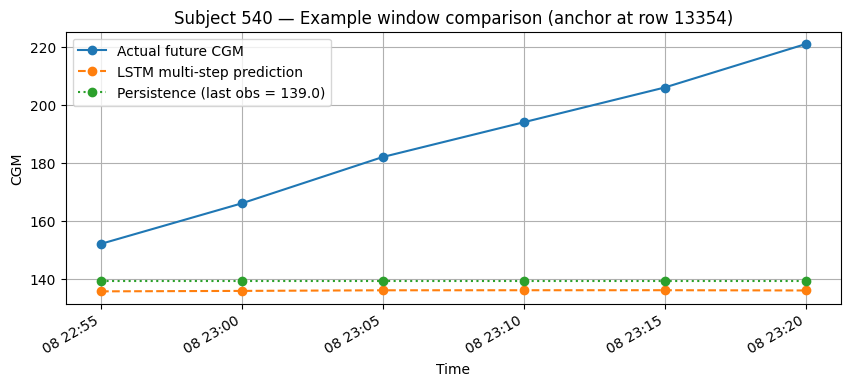

In [11]:
# CELL 1: imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility
RND = 42
np.random.seed(RND)
tf.random.set_seed(RND)

# configuration
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECT_TO_USE = None   # None -> pick first subject id found
STEP_MIN = 5            # sampling period in minutes
PRED_HORIZ_MIN = 30     # how far ahead to predict (minutes)
PAST_WINDOW_MIN = 60    # how many minutes of history to use (window)
TEST_FRACTION = 0.2     # fraction of subject time series used as test (last 20%)
BATCH_SIZE = 16
EPOCHS = 100
PATIENCE = 6
VERBOSE = 1

# derived
n_future = PRED_HORIZ_MIN // STEP_MIN         # number of future timesteps to predict
n_past = PAST_WINDOW_MIN // STEP_MIN         # number of past timesteps to feed into LSTM
print(f"Using past {n_past} steps to predict next {n_future} steps.")
# CELL 2: load + basic cleaning
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# drop rows where CGM is missing (we can't train/evaluate on missing targets)
df = df.dropna(subset=['CGM']).reset_index(drop=True)

# pick subject
subject_ids = df['id'].unique()
if SUBJECT_TO_USE is None:
    subject_id = subject_ids[0]
else:
    subject_id = SUBJECT_TO_USE
print("Subject chosen:", subject_id)

sub = df[df['id'] == subject_id].copy().reset_index(drop=True)
print("Total records for subject:", len(sub))
if len(sub) < (n_past + n_future + 10):
    raise ValueError("Not enough samples for the chosen subject. Reduce window/horizon or pick another subject.")
# CELL 3: feature selection + scaling
# choose numeric features to use as multi-input. Drop identity fields.
drop_cols = ['date','id','insulin_type','gender']   # can be modified to include encoded categorical features
feature_cols = [c for c in sub.columns if c not in drop_cols + ['CGM']]

print("Using features:", feature_cols)

# Fill small gaps (if you want) - here we'll forward-fill numeric features, then drop any remaining NaNs
sub[feature_cols + ['CGM']] = sub[feature_cols + ['CGM']].ffill().bfill()
sub = sub.dropna(subset=['CGM']).reset_index(drop=True)

# scalers (fit on train only later — but we need scalers defined now)
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# We'll split into train/test first, then fit scalers on train to avoid leakage.
split_idx = int((1 - TEST_FRACTION) * len(sub))
train_df = sub.iloc[:split_idx].reset_index(drop=True)
test_df  = sub.iloc[split_idx:].reset_index(drop=True)

# Fit scalers on training portion
X_train_vals = train_df[feature_cols].values
y_train_vals = train_df[['CGM']].values

X_scaler.fit(X_train_vals)
y_scaler.fit(y_train_vals)

# Apply scaling to whole subject (we will use scaled arrays when building sequences)
sub_scaled = sub.copy()
sub_scaled[feature_cols] = X_scaler.transform(sub[feature_cols].values)
sub_scaled['CGM'] = y_scaler.transform(sub[['CGM']].values)
# CELL 4: sequence builder for multi-step, multi-input
def build_sequences(df_scaled, feature_cols, target_col='CGM', n_past=12, n_future=6):
    """
    Build supervised sequences:
      X shape -> (samples, n_past, n_features)
      y shape -> (samples, n_future)
    We assume consecutive rows correspond to consecutive time-steps (uniform sampling).
    """
    X, y = [], []
    total_len = len(df_scaled)
    for end_idx in range(n_past - 1, total_len - n_future):
        start_idx = end_idx - (n_past - 1)
        X_seq = df_scaled.iloc[start_idx:end_idx+1][feature_cols].values
        y_seq = df_scaled.iloc[end_idx+1 : end_idx+1 + n_future][target_col].values  # shape (n_future,)
        if X_seq.shape[0] == n_past and y_seq.shape[0] == n_future:
            X.append(X_seq)
            y.append(y_seq)
    X = np.array(X)
    y = np.array(y)
    return X, y

# build sequences from scaled dataframe
X_all, y_all = build_sequences(sub_scaled, feature_cols, 'CGM', n_past=n_past, n_future=n_future)
print("Built sequences -> X:", X_all.shape, "y:", y_all.shape)

# Now split X_all/y_all into train/test according to the split index we computed earlier.
# We need to map sample indices back to original df rows: the first supervised sample uses rows [0..n_past-1] -> label starts at n_past
# So supervised sample i corresponds to end_idx = n_past-1 + i. So we can compute the number of supervised samples in train by
first_label_index = n_past  # the y for the first sample is at row index n_past
# compute number of supervised samples whose label row < split_idx (i.e., belong to train)
train_samples = max(0, split_idx - first_label_index)
print("Approx supervised train samples:", train_samples)

X_train = X_all[:train_samples]
y_train = y_all[:train_samples]
X_test  = X_all[train_samples:]
y_test  = y_all[train_samples:]

print("Final shapes -> X_train:", X_train.shape, "y_train:", y_train.shape, "X_test:", X_test.shape, "y_test:", y_test.shape)

if X_train.shape[0] < 10:
    print("Warning: very few train samples; consider reducing windows or using more subjects.")
# CELL 5: build the LSTM model
n_features = X_train.shape[2]
print("n_past, n_future, n_features:", n_past, n_future, n_features)

def make_lstm_model(n_past, n_features, n_future):
    model = Sequential()
    model.add(LSTM(64, input_shape=(n_past, n_features), return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(n_future, activation='linear'))   # predict raw scaled CGM for each horizon step
    model.compile(optimizer='adam', loss='mse')
    return model

model = make_lstm_model(n_past, n_features, n_future)
model.summary()
# CELL 6: train the model
es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=VERBOSE
)
# CELL 7: predict on test set, invert scaling, compute metrics, compare to persistence baseline
# predict (scaled)
y_pred_scaled = model.predict(X_test)

# invert scaling: y_scaler was fit on single-column CGM; to inverse_transform we need shape (n_samples*n_future, 1)
y_pred_flat = y_pred_scaled.reshape(-1, 1)
y_test_flat = y_test.reshape(-1, 1)

y_pred_inv = y_scaler.inverse_transform(y_pred_flat).ravel()
y_test_inv = y_scaler.inverse_transform(y_test_flat).ravel()

mse_lstm = mean_squared_error(y_test_inv, y_pred_inv)
mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)

# persistence baseline (zero-order hold): last observed CGM of anchor is X_test's last timestep target (we must get it in original scale)
# For each X_test sample, the last observed CGM corresponds to the last row of the original (pre-scaled) 'CGM' at the anchor.
# We can reconstruct using y_scaler and the scaled CGM last value from X_test features is NOT present (we used only other features).
# Instead, rebuild anchor last CGM from the unscaled sub data: easiest is to rebuild anchors in the unscaled series.
# Simpler approach: compute persistence predictions by taking y_true's first past-step true value in original series.
# We'll reconstruct anchor index mapping to original dataframe to get last observed CGM for each anchor:
# anchor_end_idx for supervised sample i = n_past - 1 + i

anchor_end_indices = np.arange(n_past - 1, n_past - 1 + X_all.shape[0])  # end_idx for all supervised samples (relative to sub)
anchor_end_indices_test = anchor_end_indices[train_samples:]  # indices for test supervised samples

# last observed CGM values (original scale)
last_cgms = sub.loc[anchor_end_indices_test, 'CGM'].values  # these are original unscaled CGM values (since sub is original)
# persistence replicate for n_future steps and flatten
y_persistence_flat = np.repeat(last_cgms[:, None], n_future, axis=1).reshape(-1)

mse_persist = mean_squared_error(y_test_inv, y_persistence_flat)
mae_persist = mean_absolute_error(y_test_inv, y_persistence_flat)

print("Results (flattened across horizon):")
print(f" LSTM   -> MSE: {mse_lstm:.3f}, MAE: {mae_lstm:.3f}")
print(f" Persist-> MSE: {mse_persist:.3f}, MAE: {mae_persist:.3f}")
# CELL 8: per-horizon metrics (optional) + printing count
# compute metrics per horizon step (1..n_future)
y_test_by_h = y_test.reshape(-1, n_future)  # scaled -> need inverse
y_pred_by_h = y_pred_scaled.reshape(-1, n_future)
y_test_by_h_inv = y_scaler.inverse_transform(y_test_by_h.reshape(-1,1)).reshape(-1, n_future)
y_pred_by_h_inv = y_scaler.inverse_transform(y_pred_by_h.reshape(-1,1)).reshape(-1, n_future)

print("Per-horizon MSE / MAE:")
for h in range(n_future):
    mse_h = mean_squared_error(y_test_by_h_inv[:,h], y_pred_by_h_inv[:,h])
    mae_h = mean_absolute_error(y_test_by_h_inv[:,h], y_pred_by_h_inv[:,h])
    mse_p_h = mean_squared_error(y_test_by_h_inv[:,h], np.repeat(last_cgms, 1)) if False else None  # skip direct persistence per-horizon here
    print(f"  horizon t+{(h+1)*STEP_MIN}min -> MSE: {mse_h:.3f}, MAE: {mae_h:.3f}")
# CELL 9: visualize an example window comparing actual vs LSTM vs persistence baseline
example_idx = max(0, X_test.shape[0] // 2)  # middle window in test split
# get anchor end index in original df and its future times
anchor_end_idx = anchor_end_indices_test[example_idx]
future_rows = sub.iloc[anchor_end_idx+1 : anchor_end_idx+1 + n_future]
times_future = future_rows['date'].values
actual_future = future_rows['CGM'].values

# LSTM predicted (inverse scaled)
pred_scaled_example = y_pred_scaled[example_idx]         # shape (n_future,)
pred_example = y_scaler.inverse_transform(pred_scaled_example.reshape(-1,1)).ravel()

# persistence predicted
persist_val = sub.loc[anchor_end_idx, 'CGM']
persist_pred = np.repeat(persist_val, n_future)

plt.figure(figsize=(10,4))
plt.plot(times_future, actual_future, marker='o', linestyle='-', label='Actual future CGM')
plt.plot(times_future, pred_example, marker='o', linestyle='--', label='LSTM multi-step prediction')
plt.plot(times_future, persist_pred, marker='o', linestyle=':', label=f'Persistence (last obs = {persist_val:.1f})')
plt.xlabel('Time')
plt.ylabel('CGM')
plt.title(f'Subject {subject_id} — Example window comparison (anchor at row {anchor_end_idx})')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()


In [3]:
# CELL 10: optional: show a small table of a few predicted windows (anchor_time, last_cgm, actual first future, predicted first future)
display_rows = min(6, X_test.shape[0])
out = []
for i in range(display_rows):
    a_idx = anchor_end_indices_test[i]
    out.append({
        "anchor_time": sub.loc[a_idx, 'date'],
        "last_cgm": sub.loc[a_idx, 'CGM'],
        "actual_first_future": sub.loc[a_idx+1, 'CGM'],
        "pred_first_future": float(y_scaler.inverse_transform(y_pred_scaled[i,0].reshape(1,1)).ravel()[0])
    })
display(pd.DataFrame(out))


,anchor_time,last_cgm,actual_first_future,pred_first_future
0,2027-07-03 17:55:00,236.0,238.0,137.051147
1,2027-07-03 18:00:00,238.0,240.0,137.051147
2,2027-07-03 18:05:00,240.0,242.0,137.051147
3,2027-07-03 18:10:00,242.0,243.0,137.051147
4,2027-07-03 18:15:00,243.0,243.0,137.051147
5,2027-07-03 18:20:00,243.0,244.0,137.051147


Lookback steps: 12 | Prediction steps: 6
Using subject: 540
Using AUX: ['carbs', 'bolus', 'basal', 'galvanic_skin_response', 'skin_temp', 'acceleration', 'workout_intensity', 'workout_duration', 'heartrate', 'air_temp', 'steps']
Windows: (14825, 12, 1)
Train: 11860 Test: 2965


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 12, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 12, 1)     │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 12, 11)    │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_10          │ (None, 12, 1)     │          0 │ input_layer_4[0]… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_10 (Any)        │ (None, 12)        │          0 │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_11          │ (None, 12, 11)    │          0 │ input_layer_5[0]… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_11 (Any)        │ (None, 12)        │          0 │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_22 (LSTM)      │ (None, 12, 64)    │     16,896 │ masking_10[0][0], │
│                     │                   │            │ any_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_24 (LSTM)      │ (None, 12, 64)    │     19,456 │ masking_11[0][0], │
│                     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 12, 64)    │          0 │ lstm_22[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 12, 64)    │          0 │ lstm_24[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_23 (LSTM)      │ (None, 32)        │     12,416 │ dropout_17[0][0], │
│                     │                   │            │ any_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ (None, 32)        │     12,416 │ dropout_18[0][0], │
│                     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 64)        │          0 │ lstm_23[0][0],    │
│ (Concatenate)       │                   │            │ lstm_25[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      8,320 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 128)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 6)         │        774 │ dropout_19[0][0]

 Total params: 70,278 (274.52 KB)

 Trainable params: 70,278 (274.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.1708 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 2/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0953 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 3/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0860 - val_loss: 0.0661 - learning_rate: 0.0010
Epoch 4/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0818 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 5/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0780 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 6/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0758 - val_loss: 0.0664 - learning_rate: 0.0010
Epoch 7/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0736 - val_loss: 0.0660 - learning_rate: 0.0010
Epoch 8/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0730 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 9/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0656 - val_loss: 0.0624 - learning_rate: 1

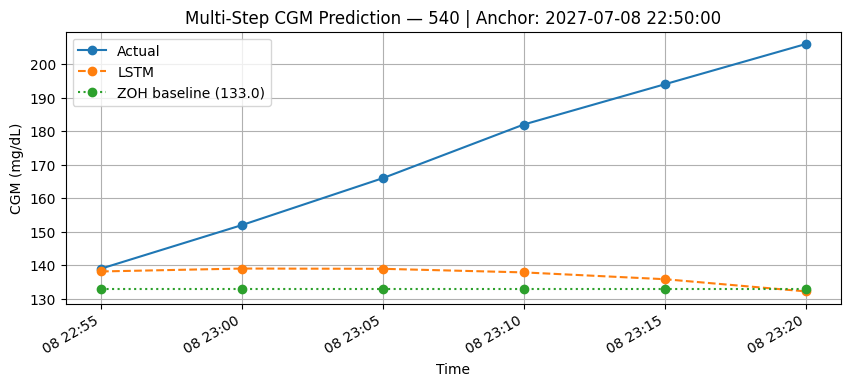

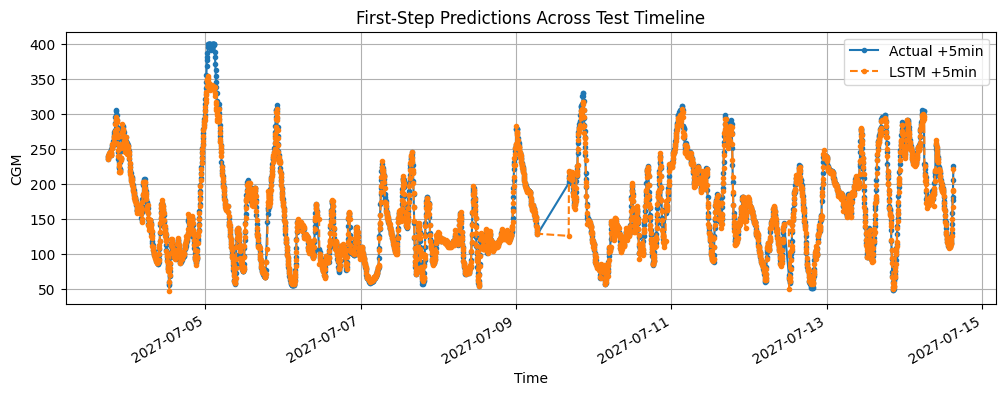

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, concatenate, Masking, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random, os

# ✅ Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ✅ Configuration
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECT_ID = None    # None -> picks the first subject
LOOKBACK_MIN = 60    # past window (minutes)
PRED_HORIZ_MIN = 30  # forecast horizon (minutes)
STEP_MIN = 5
TEST_FRACTION = 0.2
BATCH_SIZE = 16
EPOCHS = 100
LSTM_UNITS = 64
DROPOUT = 0.2

LOOKBACK_STEPS = LOOKBACK_MIN // STEP_MIN
N_PRED_STEPS = PRED_HORIZ_MIN // STEP_MIN

print("Lookback steps:", LOOKBACK_STEPS,
      "| Prediction steps:", N_PRED_STEPS)

# ✅ Load data
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# ✅ Select subject
if SUBJECT_ID is None:
    SUBJECT_ID = df['id'].unique()[0]
print("Using subject:", SUBJECT_ID)
sub = df[df['id'] == SUBJECT_ID].copy().reset_index(drop=True)

# ✅ Drop rows missing CGM
sub = sub.dropna(subset=['CGM']).reset_index(drop=True)

# ✅ Auxiliary features
aux_features = [
    'carbs','bolus','basal','galvanic_skin_response','skin_temp','acceleration',
    'workout_intensity','workout_duration','heartrate','air_temp','steps'
]
aux_features = [c for c in aux_features if c in sub.columns]
print("Using AUX:", aux_features)

sub[aux_features] = sub[aux_features].fillna(0.0)
sub['CGM'] = sub['CGM'].astype(float)

# ✅ Build sliding windows
def build_windows(data, lb, ph):
    X_cgm, X_aux, Y, times = [], [], [], []
    for i in range(len(data) - (lb + ph) + 1):
        seq = data.iloc[i:i + lb]
        future = data.iloc[i + lb:i + lb + ph]
        if future['CGM'].isnull().any():
            continue
        X_cgm.append(seq['CGM'].values.reshape(-1,1))
        X_aux.append(seq[aux_features].values)
        Y.append(future['CGM'].values)
        times.append(data.iloc[i + lb]['date'])
    return np.array(X_cgm), np.array(X_aux), np.array(Y), np.array(times)

X_cgm, X_aux, Y, T = build_windows(sub, LOOKBACK_STEPS, N_PRED_STEPS)
print("Windows:", X_cgm.shape)

# ✅ Train/test split
split = int(len(X_cgm)*(1-TEST_FRACTION))
X_cgm_tr, X_cgm_te = X_cgm[:split], X_cgm[split:]
X_aux_tr, X_aux_te = X_aux[:split], X_aux[split:]
Y_tr, Y_te = Y[:split], Y[split:]
T_te = T[split:]

print("Train:", len(X_cgm_tr), "Test:", len(X_cgm_te))

# ✅ Scaling
sc_cgm = StandardScaler().fit(X_cgm_tr.reshape(-1,1))
sc_aux = StandardScaler().fit(X_aux_tr.reshape(-1, X_aux_tr.shape[2]))
sc_y   = StandardScaler().fit(Y_tr.reshape(-1,1))

def scale(Xcgm, Xaux, Yy=None):
    Xcs = sc_cgm.transform(Xcgm.reshape(-1,1)).reshape(Xcgm.shape)
    Xas = sc_aux.transform(Xaux.reshape(-1, Xaux.shape[2])).reshape(Xaux.shape)
    if Yy is not None:
        Ys = sc_y.transform(Yy.reshape(-1,1)).reshape(Yy.shape)
        return Xcs, Xas, Ys
    return Xcs, Xas

Xc_tr_s, Xa_tr_s, Y_tr_s = scale(X_cgm_tr, X_aux_tr, Y_tr)
Xc_te_s, Xa_te_s, Y_te_s = scale(X_cgm_te, X_aux_te, Y_te)

# ✅ Build dual-input LSTM
input_cgm = Input(shape=(LOOKBACK_STEPS,1))
x1 = Masking()(input_cgm)
x1 = LSTM(LSTM_UNITS,return_sequences=True)(x1)
x1 = Dropout(DROPOUT)(x1)
x1 = LSTM(LSTM_UNITS//2)(x1)

input_aux = Input(shape=(LOOKBACK_STEPS,X_aux.shape[2]))
x2 = Masking()(input_aux)
x2 = LSTM(LSTM_UNITS,return_sequences=True)(x2)
x2 = Dropout(DROPOUT)(x2)
x2 = LSTM(LSTM_UNITS//2)(x2)

x = concatenate([x1,x2])
x = Dense(128,activation='relu')(x)
x = Dropout(DROPOUT)(x)
output = Dense(N_PRED_STEPS)(x)

model = Model(inputs=[input_cgm,input_aux], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
model.summary()

# ✅ Train model
val_split = int(0.9 * len(Xc_tr_s))
history = model.fit(
    [Xc_tr_s[:val_split], Xa_tr_s[:val_split]], Y_tr_s[:val_split],
    validation_data=([Xc_tr_s[val_split:], Xa_tr_s[val_split:]], Y_tr_s[val_split:]),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(patience=6,restore_best_weights=True),
               ReduceLROnPlateau(patience=4)],
    verbose=1
)

# ✅ Predict + inverse scale
Y_pred_s = model.predict([Xc_te_s, Xa_te_s], batch_size=BATCH_SIZE)
Y_pred = sc_y.inverse_transform(Y_pred_s.reshape(-1,1)).reshape(Y_pred_s.shape)
Y_true = Y_te

# ✅ Metrics
print("--- METRICS ---")
print("Flattened MSE:", mean_squared_error(Y_true.ravel(), Y_pred.ravel()))
print("Flattened MAE:", mean_absolute_error(Y_true.ravel(), Y_pred.ravel()))

# ✅ Per-step metrics
print("\nStep-wise metrics:")
for i in range(N_PRED_STEPS):
    mse_i = mean_squared_error(Y_true[:,i], Y_pred[:,i])
    mae_i = mean_absolute_error(Y_true[:,i], Y_pred[:,i])
    print(f" +{STEP_MIN*(i+1)} min -> MSE: {mse_i:.2f} | MAE: {mae_i:.2f}")

# ✅ Plot a single sample (mid test)
idx = len(Xc_te_s)//2
anchor_time = T_te[idx]
future_times = [anchor_time + pd.Timedelta(minutes=STEP_MIN*(i+1))
                for i in range(N_PRED_STEPS)]

# Zero-order hold baseline
last_val = X_cgm_te[idx][-1,0]
y_zero = np.repeat(last_val, N_PRED_STEPS)

plt.figure(figsize=(10,4))
plt.plot(future_times, Y_true[idx], 'o-', label='Actual')
plt.plot(future_times, Y_pred[idx], 'o--', label='LSTM')
plt.plot(future_times, y_zero,  'o:', label=f'ZOH baseline ({last_val:.1f})')
plt.grid(); plt.legend()
plt.title(f'Multi-Step CGM Prediction — {SUBJECT_ID} | Anchor: {anchor_time}')
plt.xlabel("Time"); plt.ylabel("CGM (mg/dL)")
plt.gcf().autofmt_xdate()
plt.show()

# ✅ Quick curve for first-step predictions over whole test set
plt.figure(figsize=(12,4))
plt.plot(T_te, Y_true[:,0], '.-', label='Actual +5min')
plt.plot(T_te, Y_pred[:,0], '.--', label='LSTM +5min')
plt.grid(); plt.legend()
plt.title('First-Step Predictions Across Test Timeline')
plt.ylabel("CGM"); plt.xlabel("Time")
plt.gcf().autofmt_xdate()
plt.show()


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_7196\1090767206.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_interval = df.groupby("id").apply(med_int).dropna().median()


median sampling interval = 5.00 min -> steps=6, window_steps=48
Total supervised samples: 165896
subjects total/train/test = 12/9/3
samples train/test = 124267/41629  (steps=6)
X_train shape: (124267, 48, 1), y_train shape: (124267,)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
6990/6990 ━━━━━━━━━━━━━━━━━━━━ 54s 8ms/step - loss: 0.0054 - mae: 0.0517 - val_loss: 0.0031 - val_mae: 0.0374
Epoch 2/3
6990/6990 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - loss: 0.0046 - mae: 0.0471 - val_loss: 0.0030 - val_mae: 0.0368
Epoch 3/3
6990/6990 ━━━━━━━━━━━━━━━━━━━━ 52s 8ms/step - loss: 0.0045 - mae: 0.0460 - val_loss: 0.0029 - val_mae: 0.0356
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
LSTM Test RMSE = 22.85 mg/dL, MAE = 15.99 mg/dL
Persistence baseline Test RMSE = 27.22 mg/dL, MAE = 19.36 mg/dL

-- Plots WITHOUT persistence baseline --


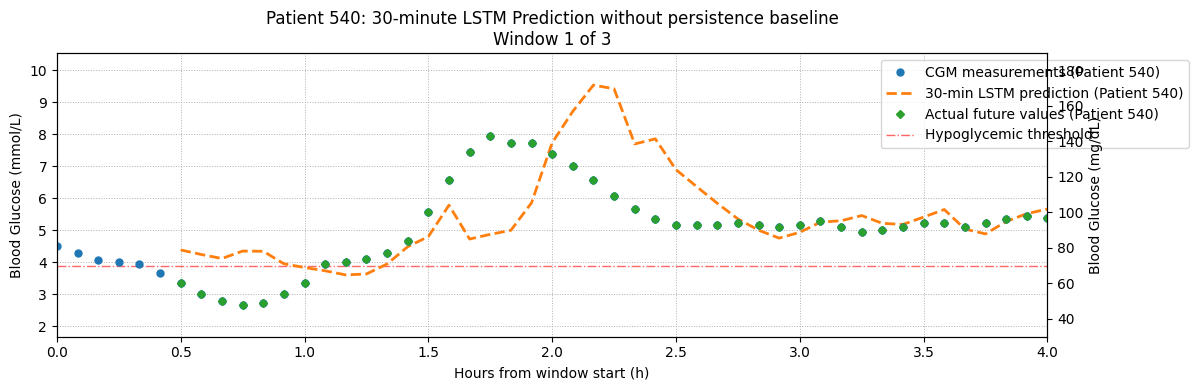

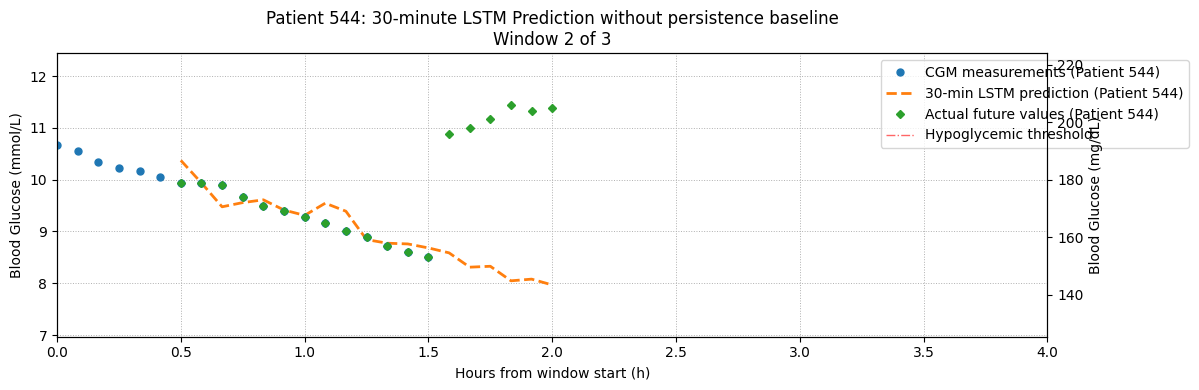

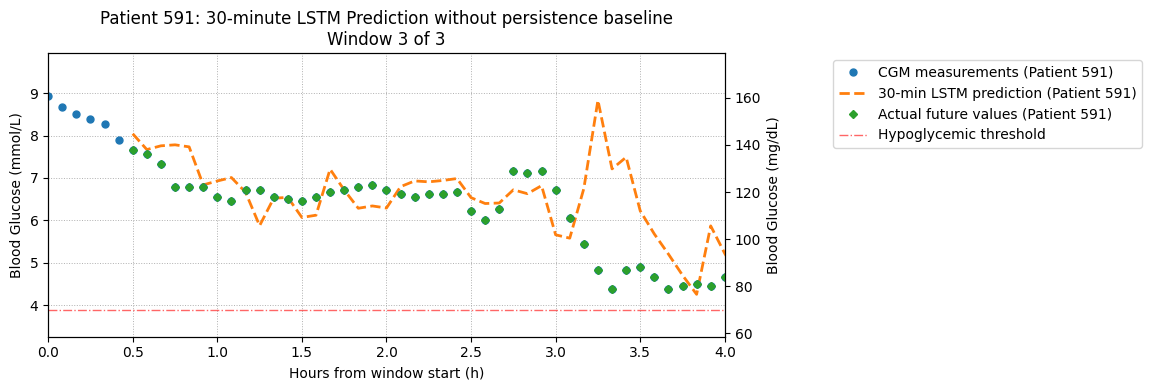


-- Plots WITH persistence baseline --


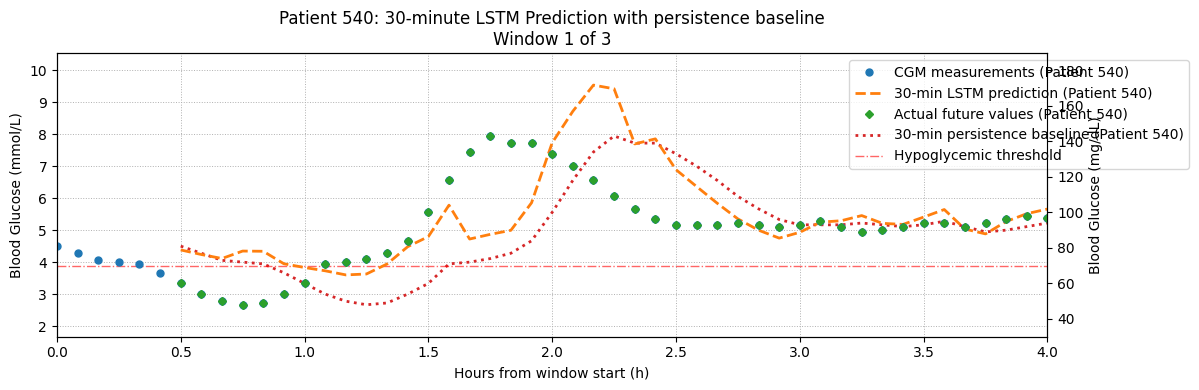

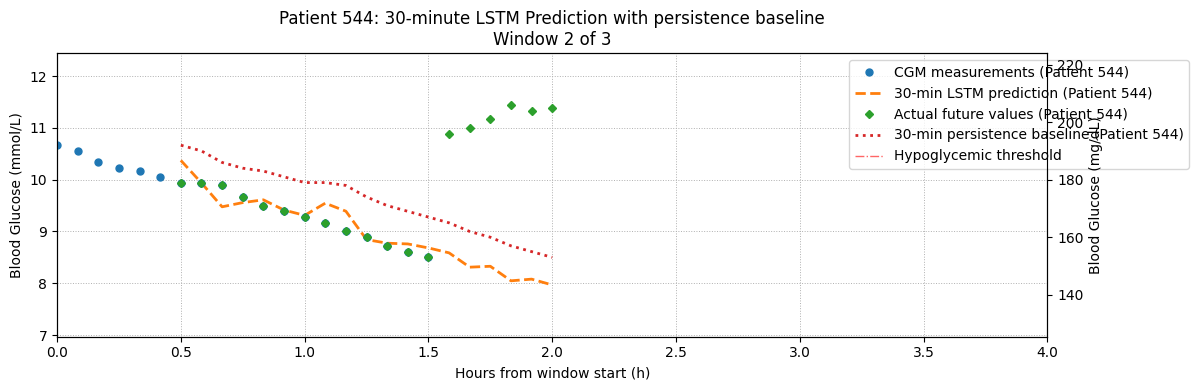

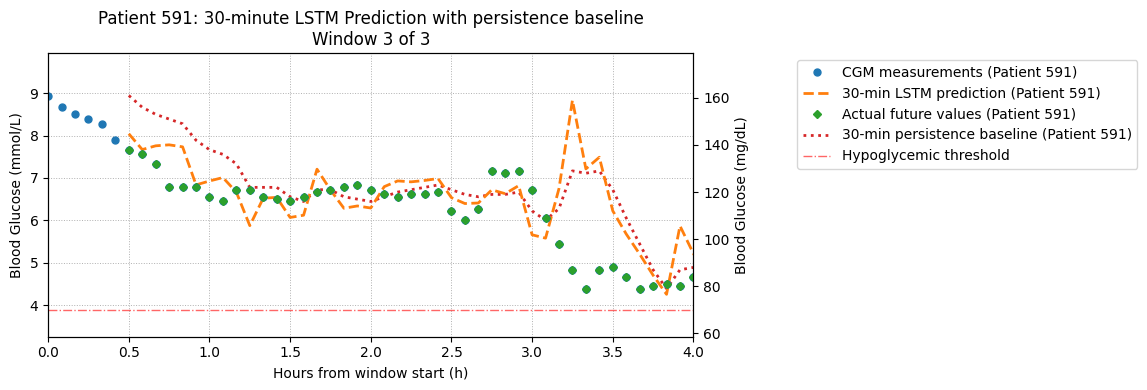

In [17]:
# LSTM prediction model for OhioT1DM (based on provided persistence baseline)
# - Produces the same type of plots as the original notebook
# - Two plotting modes: with and without the zero-order-hold (persistence) baseline
# Requirements: tensorflow, scikit-learn, pandas, matplotlib, numpy
# Usage: adjust DATA path if needed and run the script / notebook cell

import os, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# --------------------------- User settings ---------------------------
DATA = "../data/OhioT1DM.csv"   # adjust if needed
PH_MIN = 30                    # prediction horizon in minutes
TRAIN_FRACT = 0.8
WINDOW_HOURS = 4               # how many hours of past history to use as LSTM input
BATCH_SIZE = 16
EPOCHS = 3
VERBOSE = 1

if not os.path.exists(DATA):
    raise FileNotFoundError(f"File not found: {DATA}")

# --------------------------- Load & basic cleaning ---------------------------
df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["id","date"]).reset_index(drop=True)
df = df.dropna(subset=["CGM"]).copy()
df["CGM"] = pd.to_numeric(df["CGM"], errors="coerce")

# compute median sampling interval (minutes) per subject -> global median
def med_int(g):
    d = g["date"].diff().dt.total_seconds().dropna()/60.0
    return d.median() if len(d)>0 else np.nan
median_interval = df.groupby("id").apply(med_int).dropna().median()
if np.isnan(median_interval): raise RuntimeError("Cannot infer sampling interval.")
steps = max(1, int(round(PH_MIN/median_interval)))
window_steps = max(1, int(round(WINDOW_HOURS*60/median_interval)))
print(f"median sampling interval = {median_interval:.2f} min -> steps={steps}, window_steps={window_steps}")

# --------------------------- Build supervised windows for LSTM ---------------------------
# We'll build sequences of length `window_steps` that end at time t (last observation in seq),
# and the target is the CGM at t + PH_MIN (i.e., the value `steps` indices ahead)
rows = []
for sid, g in df.groupby("id"):
    g = g.reset_index(drop=True)
    if len(g) <= steps: continue
    for i in range(len(g) - steps):
        # require a full window of past samples
        if i - window_steps + 1 < 0:
            continue
        seq = g["CGM"].iloc[i - window_steps + 1: i+1].values.astype(float)
        target = g["CGM"].iloc[i + steps]
        last_date = g["date"].iloc[i]
        pred_time = last_date + pd.Timedelta(minutes=PH_MIN)
        rows.append({
            "id": sid,
            "date": last_date,
            "pred_time": pred_time,
            "seq": seq,
            "last_cgm": seq[-1],
            "target_CGM": float(target)
        })

data = pd.DataFrame(rows)
if data.empty: raise RuntimeError("No supervised samples found.")
print(f"Total supervised samples: {len(data)}")

# --------------------------- Subject-level split (no leakage) ---------------------------
subjects = sorted(data["id"].unique()); random.shuffle(subjects)
ntrain = int(len(subjects)*TRAIN_FRACT)
train_s = set(subjects[:ntrain]); test_s = set(subjects[ntrain:])
train_df = data[data["id"].isin(train_s)].reset_index(drop=True)
test_df  = data[data["id"].isin(test_s)].reset_index(drop=True)
print(f"subjects total/train/test = {len(subjects)}/{len(train_s)}/{len(test_s)}")
print(f"samples train/test = {len(train_df)}/{len(test_df)}  (steps={steps})")

# --------------------------- Scaling ---------------------------
# Fit a MinMax scaler on TRAIN values (both sequences and targets) to keep scale [0,1]
scaler = MinMaxScaler(feature_range=(0,1))
# concatenate all sequence values from train to fit
train_values = np.concatenate(train_df['seq'].values).reshape(-1,1)
scaler.fit(train_values)

# helper to transform sequences and targets
def transform_seq_array(seq_list, scaler):
    X = np.stack([scaler.transform(s.reshape(-1,1)).reshape(-1) for s in seq_list])
    return X[..., np.newaxis]  # shape (n, seq_len, 1)

X_train = transform_seq_array(train_df['seq'].values, scaler)
y_train = scaler.transform(train_df[['target_CGM']].values).reshape(-1)
X_test  = transform_seq_array(test_df['seq'].values, scaler)
y_test  = scaler.transform(test_df[['target_CGM']].values).reshape(-1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# --------------------------- Build LSTM model ---------------------------
seq_len = X_train.shape[1]
model = Sequential([
    LSTM(64, input_shape=(seq_len,1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_split=0.1, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, callbacks=[es], verbose=VERBOSE)

# --------------------------- Evaluate on test set ---------------------------
y_pred_scaled = model.predict(X_test).reshape(-1)
# invert scaling
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1)
y_true = scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

rmse_mgdl = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mgdl  = mean_absolute_error(y_true, y_pred)
print(f"LSTM Test RMSE = {rmse_mgdl:.2f} mg/dL, MAE = {mae_mgdl:.2f} mg/dL")

# Persistence baseline for comparison (zero-order hold: last observed CGM)
y_persist = test_df['last_cgm'].values
rmse_p = np.sqrt(mean_squared_error(y_true, y_persist))
mae_p  = mean_absolute_error(y_true, y_persist)
print(f"Persistence baseline Test RMSE = {rmse_p:.2f} mg/dL, MAE = {mae_p:.2f} mg/dL")

# attach predictions to test_df for plotting
test_df = test_df.copy()
test_df['pred_lstm'] = y_pred
test_df['pred_persistence'] = y_persist

# Convert to mmol/L for plotting (1 mmol/L = 18 mg/dL)
test_df['target_mmol'] = test_df['target_CGM']/18.0
test_df['pred_lstm_mmol'] = test_df['pred_lstm']/18.0
test_df['pred_persistence_mmol'] = test_df['pred_persistence']/18.0
# for 'actual' measurement points we will also mark last observation (the one used by model)
test_df['actual_mmol'] = test_df['last_cgm']/18.0

# --------------------------- Plotting routine ---------------------------
hyp_mmol = 70.0/18.0

def plot_windows(test_df, with_baseline=True, max_windows=3, window_hours=WINDOW_HOURS):
    test_subjects = list(test_df['id'].unique())[:6]
    count = 0
    for sid in test_subjects:
        if count >= max_windows: break
        sub = test_df[test_df['id']==sid].sort_values('date').reset_index(drop=True)
        if len(sub) < 5: continue
        start = sub['date'].iloc[0]
        mask = ((sub['date'] - start).dt.total_seconds() <= window_hours*3600) | \
               ((sub['pred_time'] - start).dt.total_seconds() <= window_hours*3600)
        win = sub.loc[mask].copy()
        if win.empty: continue

        x_actual = (win['date'] - start).dt.total_seconds()/3600.0
        x_pred   = (win['pred_time'] - start).dt.total_seconds()/3600.0

        fig, ax1 = plt.subplots(figsize=(12,4))
        l1 = ax1.plot(x_actual, win['actual_mmol'], 'o', markersize=5, label=f"CGM measurements (Patient {sid})", zorder=4)
        # LSTM predictions (dashed)
        order = np.argsort(x_pred)
        l2 = ax1.plot(x_pred.values[order], win['pred_lstm_mmol'].values[order], linestyle='--', linewidth=2,
                      label=f"{PH_MIN}-min LSTM prediction (Patient {sid})", zorder=3)
        # actual future values
        l3 = ax1.plot(x_pred, win['target_mmol'], 'D', markersize=4, label=f"Actual future values (Patient {sid})", zorder=5)
        # optional persistence baseline
        if with_baseline:
            l4 = ax1.plot(x_pred.values[order], win['pred_persistence_mmol'].values[order], linestyle=':', linewidth=2,
                          label=f"{PH_MIN}-min persistence baseline (Patient {sid})", zorder=2)

        ax1.set_xlim(0, window_hours)
        ax1.set_ylim(max(0, min(win['actual_mmol'].min(), win['pred_lstm_mmol'].min(), win['target_mmol'].min())-1),
                     max(win['actual_mmol'].max(), win['pred_lstm_mmol'].max(), win['target_mmol'].max())+1)
        ax1.set_xlabel("Hours from window start (h)")
        ax1.set_ylabel("Blood Glucose (mmol/L)")
        ax1.grid(linestyle=':', linewidth=0.7)

        ax2 = ax1.twinx()
        ax2.set_ylim(ax1.get_ylim()[0]*18, ax1.get_ylim()[1]*18)
        ax2.set_ylabel("Blood Glucose (mg/dL)")

        # hypoglycemia threshold
        l5 = ax1.axhline(hyp_mmol, linestyle='-.', linewidth=1, alpha=0.6, color='red', label='Hypoglycemic threshold')

        # combine legend
        # ax.plot returns a list of Line2D objects; ensure we flatten them into a single list
        lines = []
        lines.extend(l1)   # l1 is a list
        lines.extend(l2)
        lines.extend(l3)
        if with_baseline:
            lines.extend(l4)
        lines.append(l5)   # l5 is a single Line2D
        labels = [ln.get_label() for ln in lines]
        ax1.legend(lines, labels, bbox_to_anchor=(1.15,1))

        plt.title(f"Patient {sid}: {PH_MIN}-minute LSTM Prediction {'with' if with_baseline else 'without'} persistence baseline\nWindow {count+1} of {max_windows}")
        plt.tight_layout()
        plt.show()
        count += 1

# --------------------------- Show plots ---------------------------
print('\n-- Plots WITHOUT persistence baseline --')
plot_windows(test_df, with_baseline=False)
print('\n-- Plots WITH persistence baseline --')
plot_windows(test_df, with_baseline=True)

# --------------------------- End of script ---------------------------

# Notes:
# - The script trains an LSTM to predict CGM at PH_MIN minutes using WINDOW_HOURS of past data.
# - Adjust hyperparameters near the top (EPOCHS, BATCH_SIZE, model architecture) to improve performance.
# - If the dataset is large or your machine has limited RAM/GPU, reduce batch size or WINDOW_HOURS.

C:\Users\mohamesb\AppData\Local\Temp\ipykernel_7196\1163651562.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_interval = df.groupby("id").apply(med_int).dropna().median()


median sampling interval = 5.00 min -> steps=6, window_steps=48
Total supervised samples: 165896
subjects total/train/test = 12/9/3
samples train/test = 124267/41629  (steps=6)
X_train shape: (124267, 48, 1), y_train shape: (124267,)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
6990/6990 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - loss: 0.0054 - mae: 0.0517 - val_loss: 0.0031 - val_mae: 0.0374
Epoch 2/3
6990/6990 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - loss: 0.0046 - mae: 0.0471 - val_loss: 0.0030 - val_mae: 0.0368
Epoch 3/3
6990/6990 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - loss: 0.0045 - mae: 0.0460 - val_loss: 0.0029 - val_mae: 0.0356
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
LSTM Test RMSE = 22.85 mg/dL, MAE = 15.99 mg/dL
Persistence baseline Test RMSE = 27.22 mg/dL, MAE = 19.36 mg/dL
-- Plots WITHOUT persistence baseline (predictions shown at current time) --


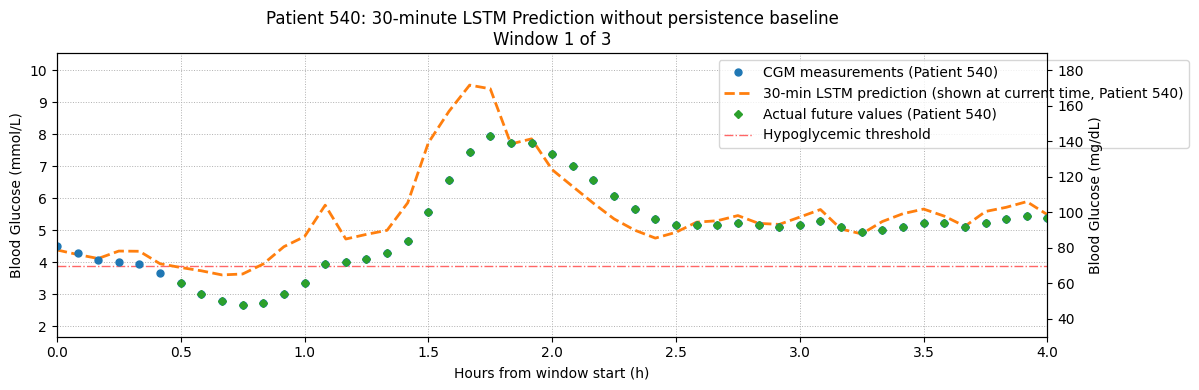

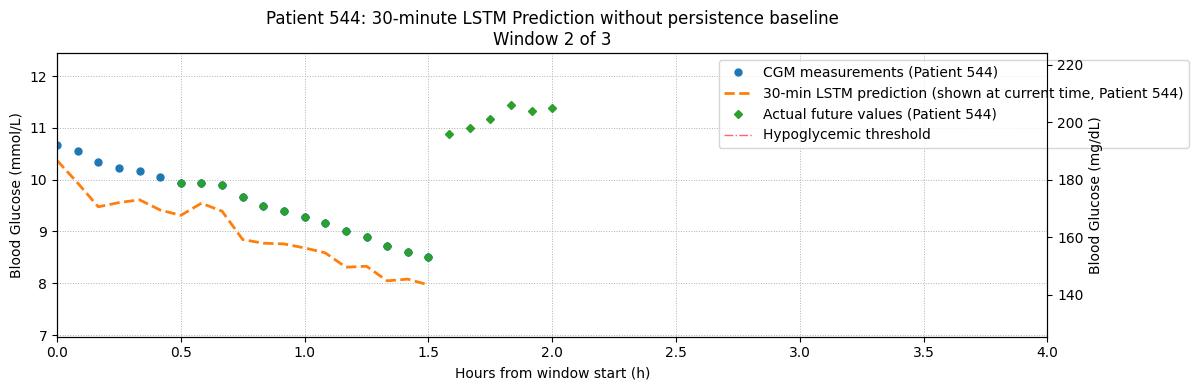

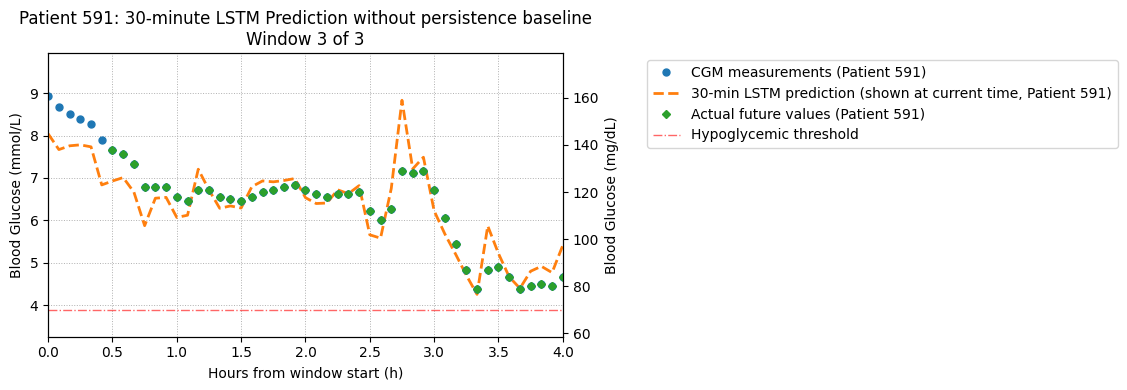

-- Plots WITH persistence baseline (predictions shown at current time) --


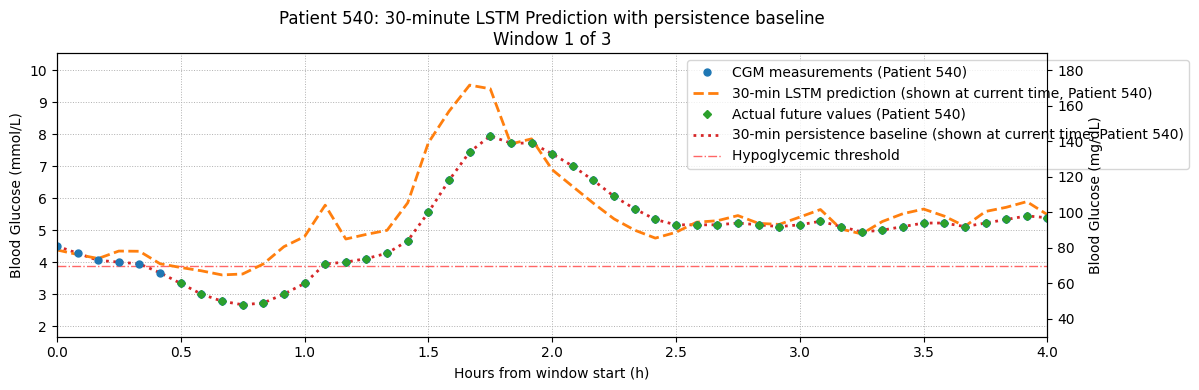

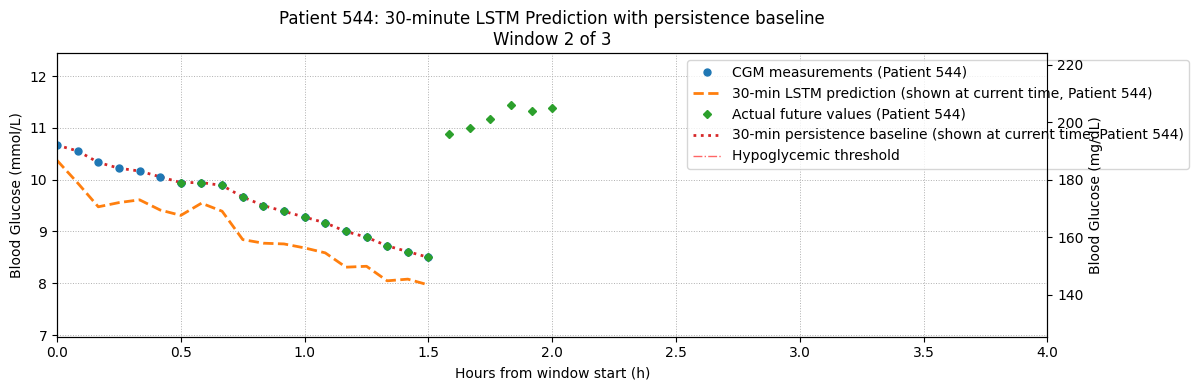

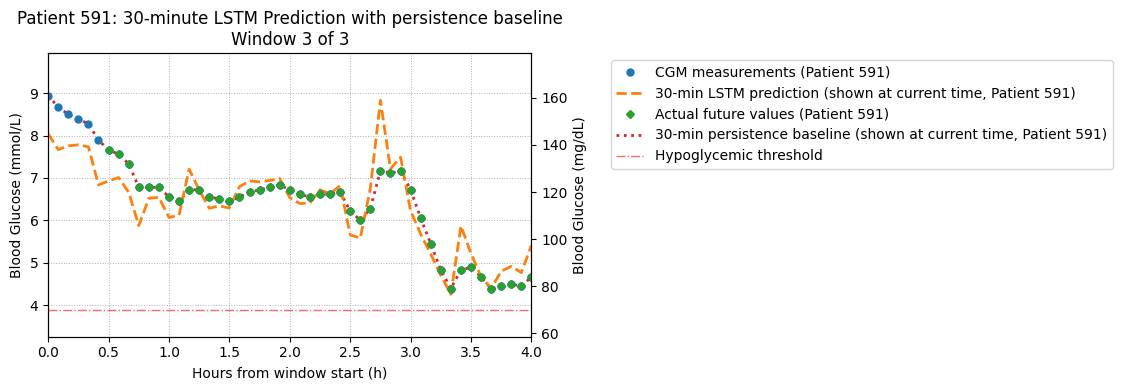

In [18]:
# LSTM prediction model for OhioT1DM (based on provided persistence baseline)
# - Produces the same type of plots as the original notebook
# - Two plotting modes: with and without the zero-order-hold (persistence) baseline
# - CHANGE: predictions are shown at the *current* time (the time of the last observed sample)
#   while the model still predicts the glucose value at PH_MIN minutes in the future.
# Requirements: tensorflow, scikit-learn, pandas, matplotlib, numpy
# Usage: adjust DATA path if needed and run the script / notebook cell

import os, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# --------------------------- User settings ---------------------------
DATA = "../data/OhioT1DM.csv"   # adjust if needed
PH_MIN = 30                    # prediction horizon in minutes (model predicts t + PH_MIN)
TRAIN_FRACT = 0.8
WINDOW_HOURS = 4               # how many hours of past history to use as LSTM input
BATCH_SIZE = 16
EPOCHS = 3
VERBOSE = 1

if not os.path.exists(DATA):
    raise FileNotFoundError(f"File not found: {DATA}")

# --------------------------- Load & basic cleaning ---------------------------
df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["id","date"]).reset_index(drop=True)
df = df.dropna(subset=["CGM"]).copy()
df["CGM"] = pd.to_numeric(df["CGM"], errors="coerce")

# compute median sampling interval (minutes) per subject -> global median
def med_int(g):
    d = g["date"].diff().dt.total_seconds().dropna()/60.0
    return d.median() if len(d)>0 else np.nan
median_interval = df.groupby("id").apply(med_int).dropna().median()
if np.isnan(median_interval): raise RuntimeError("Cannot infer sampling interval.")
steps = max(1, int(round(PH_MIN/median_interval)))
window_steps = max(1, int(round(WINDOW_HOURS*60/median_interval)))
print(f"median sampling interval = {median_interval:.2f} min -> steps={steps}, window_steps={window_steps}")

# --------------------------- Build supervised windows for LSTM ---------------------------
# We'll build sequences of length `window_steps` that end at time t (last observation in seq),
# and the target is the CGM at t + PH_MIN (i.e., the value `steps` indices ahead)
rows = []
for sid, g in df.groupby("id"):
    g = g.reset_index(drop=True)
    if len(g) <= steps: continue
    for i in range(len(g) - steps):
        # require a full window of past samples
        if i - window_steps + 1 < 0:
            continue
        seq = g["CGM"].iloc[i - window_steps + 1: i+1].values.astype(float)
        target = g["CGM"].iloc[i + steps]
        last_date = g["date"].iloc[i]
        pred_time = last_date + pd.Timedelta(minutes=PH_MIN)
        rows.append({
            "id": sid,
            "date": last_date,
            "pred_time": pred_time,
            "seq": seq,
            "last_cgm": seq[-1],
            "target_CGM": float(target)
        })

data = pd.DataFrame(rows)
if data.empty: raise RuntimeError("No supervised samples found.")
print(f"Total supervised samples: {len(data)}")

# --------------------------- Subject-level split (no leakage) ---------------------------
subjects = sorted(data["id"].unique()); random.shuffle(subjects)
ntrain = int(len(subjects)*TRAIN_FRACT)
train_s = set(subjects[:ntrain]); test_s = set(subjects[ntrain:])
train_df = data[data["id"].isin(train_s)].reset_index(drop=True)
test_df  = data[data["id"].isin(test_s)].reset_index(drop=True)
print(f"subjects total/train/test = {len(subjects)}/{len(train_s)}/{len(test_s)}")
print(f"samples train/test = {len(train_df)}/{len(test_df)}  (steps={steps})")

# --------------------------- Scaling ---------------------------
# Fit a MinMax scaler on TRAIN values (both sequences and targets) to keep scale [0,1]
scaler = MinMaxScaler(feature_range=(0,1))
# concatenate all sequence values from train to fit
train_values = np.concatenate(train_df['seq'].values).reshape(-1,1)
scaler.fit(train_values)

# helper to transform sequences and targets
def transform_seq_array(seq_list, scaler):
    X = np.stack([scaler.transform(s.reshape(-1,1)).reshape(-1) for s in seq_list])
    return X[..., np.newaxis]  # shape (n, seq_len, 1)

X_train = transform_seq_array(train_df['seq'].values, scaler)
y_train = scaler.transform(train_df[['target_CGM']].values).reshape(-1)
X_test  = transform_seq_array(test_df['seq'].values, scaler)
y_test  = scaler.transform(test_df[['target_CGM']].values).reshape(-1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# --------------------------- Build LSTM model ---------------------------
seq_len = X_train.shape[1]
model = Sequential([
    LSTM(64, input_shape=(seq_len,1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_split=0.1, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, callbacks=[es], verbose=VERBOSE)

# --------------------------- Evaluate on test set ---------------------------
y_pred_scaled = model.predict(X_test).reshape(-1)
# invert scaling
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1)
y_true = scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

rmse_mgdl = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mgdl  = mean_absolute_error(y_true, y_pred)
print(f"LSTM Test RMSE = {rmse_mgdl:.2f} mg/dL, MAE = {mae_mgdl:.2f} mg/dL")

# Persistence baseline for comparison (zero-order hold: last observed CGM)
y_persist = test_df['last_cgm'].values
rmse_p = np.sqrt(mean_squared_error(y_true, y_persist))
mae_p  = mean_absolute_error(y_true, y_persist)
print(f"Persistence baseline Test RMSE = {rmse_p:.2f} mg/dL, MAE = {mae_p:.2f} mg/dL")

# attach predictions to test_df for plotting
test_df = test_df.copy()
test_df['pred_lstm'] = y_pred
test_df['pred_persistence'] = y_persist

# Convert to mmol/L for plotting (1 mmol/L = 18 mg/dL)
test_df['target_mmol'] = test_df['target_CGM']/18.0
# We'll display the model's predicted future glucose value at the *current* time ('date')
test_df['pred_lstm_mmol'] = test_df['pred_lstm']/18.0
test_df['pred_persistence_mmol'] = test_df['pred_persistence']/18.0
# for 'actual' measurement points we will also mark last observation (the one used by model)
test_df['actual_mmol'] = test_df['last_cgm']/18.0

# --------------------------- Plotting routine (PREDICTIONS SHOWN AT CURRENT TIME) ---------------------------
hyp_mmol = 70.0/18.0

def plot_windows(test_df, with_baseline=True, max_windows=3, window_hours=WINDOW_HOURS):
    """
    Plot windows where:
      - actual measurements are shown at their original times (win['date'])
      - model predictions (and optional persistence baseline) are plotted at the *current* time (win['date'])
        because these are the values available to the clinician/user at time t (they represent the expected
        glucose at t + PH_MIN, but the prediction is made at time t).
      - the actual future values (ground truth at t + PH_MIN) are shown at win['pred_time'] (as diamonds).
    """
    test_subjects = list(test_df['id'].unique())[:6]
    count = 0
    for sid in test_subjects:
        if count >= max_windows: break
        sub = test_df[test_df['id']==sid].sort_values('date').reset_index(drop=True)
        if len(sub) < 5: continue
        start = sub['date'].iloc[0]
        mask = ((sub['date'] - start).dt.total_seconds() <= window_hours*3600) | \
               ((sub['pred_time'] - start).dt.total_seconds() <= window_hours*3600)
        win = sub.loc[mask].copy()
        if win.empty: continue

        x_actual = (win['date'] - start).dt.total_seconds()/3600.0    # time axis for measurements & predictions
        x_pred   = (win['pred_time'] - start).dt.total_seconds()/3600.0  # time axis for future ground-truth

        fig, ax1 = plt.subplots(figsize=(12,4))

        # Plot CGM measurements (current-time dots)
        l1 = ax1.plot(x_actual, win['actual_mmol'], 'o', markersize=5, label=f"CGM measurements (Patient {sid})", zorder=4)

        # Plot LSTM predictions AT current time (same x as actual measurements)
        order_actual = np.argsort(x_actual)
        l2 = ax1.plot(x_actual.values[order_actual], win['pred_lstm_mmol'].values[order_actual], linestyle='--', linewidth=2,
                      label=f"{PH_MIN}-min LSTM prediction (shown at current time, Patient {sid})", zorder=3)

        # Plot the actual future values at their future time (diamonds)
        l3 = ax1.plot(x_pred, win['target_mmol'], 'D', markersize=4, label=f"Actual future values (Patient {sid})", zorder=5)

        # optional persistence baseline shown at current time (same x as measurements)
        if with_baseline:
            l4 = ax1.plot(x_actual.values[order_actual], win['pred_persistence_mmol'].values[order_actual], linestyle=':', linewidth=2,
                          label=f"{PH_MIN}-min persistence baseline (shown at current time, Patient {sid})", zorder=2)

        # adjust y limits to include all series
        ymin = max(0, min(win['actual_mmol'].min(), win['pred_lstm_mmol'].min(), win['target_mmol'].min()) - 1)
        ymax = max(win['actual_mmol'].max(), win['pred_lstm_mmol'].max(), win['target_mmol'].max()) + 1
        ax1.set_xlim(0, window_hours)
        ax1.set_ylim(ymin, ymax)
        ax1.set_xlabel("Hours from window start (h)")
        ax1.set_ylabel("Blood Glucose (mmol/L)")
        ax1.grid(linestyle=':', linewidth=0.7)

        # Second axis in mg/dL
        ax2 = ax1.twinx()
        ax2.set_ylim(ax1.get_ylim()[0]*18, ax1.get_ylim()[1]*18)
        ax2.set_ylabel("Blood Glucose (mg/dL)")

        l5 = ax1.axhline(hyp_mmol, linestyle='-.', linewidth=1, alpha=0.6, color='red', label='Hypoglycemic threshold')

        # combine legend
        # ax.plot returns a list of Line2D objects; ensure we flatten them into a single list
        lines = []
        lines.extend(l1)   # l1 is a list
        lines.extend(l2)
        lines.extend(l3)
        if with_baseline:
            lines.extend(l4)
        lines.append(l5)   # l5 is a single Line2D
        labels = [ln.get_label() for ln in lines]
        ax1.legend(lines, labels, bbox_to_anchor=(1.15,1))

        plt.title(f"Patient {sid}: {PH_MIN}-minute LSTM Prediction {'with' if with_baseline else 'without'} persistence baseline\nWindow {count+1} of {max_windows}")
        plt.tight_layout()
        plt.show()
        count += 1

# --------------------------- Show plots ---------------------------
print('-- Plots WITHOUT persistence baseline (predictions shown at current time) --')
plot_windows(test_df, with_baseline=False)
print('-- Plots WITH persistence baseline (predictions shown at current time) --')
plot_windows(test_df, with_baseline=True)

# --------------------------- End of script ---------------------------

# Explanation for the change:
# - The LSTM model still *learns* to predict the glucose value at t + PH_MIN (i.e. 30 minutes ahead).
# - In real-time use you make that prediction at time t (when the last measurement arrived). Showing the
#   predicted value at the *current* time (t) makes the plots reflect what a clinician/user would see right now
#   (the numeric prediction represents a future glucose value, but the point is available now).
# - If instead you want the model to predict the *current* glucose (i.e. reconstruct/smooth the present value),
#   then you would set target_CGM = CGM at time t and retrain; that's a different modeling goal.

# If you'd like, I can also:
# - change the model to explicitly predict the value at the current time (reconstruction), or
# - provide deployment-style plots that show how predictions would be used in a live streaming setting.
# Tell me which one and I'll update the canvas content accordingly.
